In [11]:
from dotenv import load_dotenv

load_dotenv()

True

In [12]:
from langchain_google_genai import ChatGoogleGenerativeAI

model = ChatGoogleGenerativeAI(model="gemini-2.0-flash")

In [ ]:
from typing import Annotated # annotated는 타입 힌트를 사용할 때 사용하는 함수
from typing_extensions import TypedDict # TypedDict는 딕셔너리 타입을 정의할 때 사용하는 함수

from langgraph.graph.message import add_messages
from langchain_core.messages import AnyMessage # HumanMessage, AIMessage, SystemMessage, ToolMessage, FunctionMessage를 나타내는 추상화된 타입

# 상태 정의
class State(TypedDict):	
    # messages: list[Annotated[AnyMessage, add_messages]] # * list 전체에 add_messages 함수가 적용(멀티턴 안됨)
    messages: Annotated[AnyMessage, add_messages] # 개별 메시지(AnyMessage)에 add_messages 함수가 적용

In [14]:
from langgraph.graph import StateGraph

# 그래프 생성
graph_builder = StateGraph(State)

In [15]:
def generate(state: State):
    return {"messages": [model.invoke(state["messages"])]}

graph_builder.add_node("generate", generate)

In [16]:
from langgraph.graph import START, END

graph_builder.add_edge(START, "generate")
graph_builder.add_edge("generate", END)

#### 체크포인트

에이전트의 현재 상태를 저장하여 나중에 중단된 시점부터 다시 시작하거나, 특정 시점으로 돌아갈 수 있게 하는 기능

In [17]:
from langgraph.checkpoint.memory import MemorySaver # 체크포인트 저장소 중 하나
memory = MemorySaver()

config = {"configurable": {"thread_id": "kim1"}} # thread_id별로 여러 대화 스레드의 상태를 독립적으로 관리

graph = graph_builder.compile(checkpointer=memory)

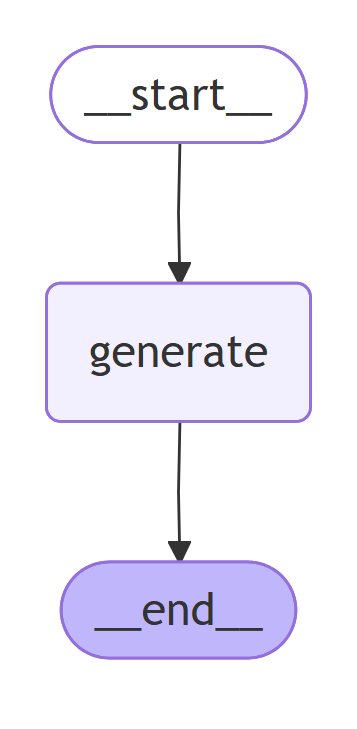

In [18]:
import nest_asyncio
from IPython.display import display, Image
from langchain_core.runnables.graph_mermaid import MermaidDrawMethod

# nest_asyncio를 적용하여 이벤트 루프 중첩 오류를 해결한다.
nest_asyncio.apply()

# (옵션) 그래프를 시각화
# 이 코드는 이미 langchain_core 라이브러리의 pyppeteer.launch()에 
# executablePath가 하드코딩된 상태를 전제로 한다.
display(Image(graph.get_graph().draw_mermaid_png(draw_method=MermaidDrawMethod.PYPPETEER)))

In [19]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception: 
    pass

In [20]:
from langchain.schema import HumanMessage

while True:
    user_input = input("You\t:")
    
    if user_input in ["exit", "quit", "q"]:
        break

    for event in graph.stream({
        "messages": [HumanMessage(user_input)]},
        config, # * 추가
        stream_mode="values"
    ):
        event["messages"][-1].pretty_print()

    print(f'\n(현재 메시지 개수: {len(event["messages"])})\n')

================================ Human Message =================================

내 이름은 김일남이야
================================== Ai Message ==================================

안녕하세요, 김일남 님! 만나서 반갑습니다. 무엇을 도와드릴까요?

(현재 메시지 개수: 2)

================================ Human Message =================================

내 이름은 뭐지?
================================== Ai Message ==================================

당신의 이름은 김일남입니다.

(현재 메시지 개수: 4)

